# Exploratory data analysis

## 1-Environmental Setup & Sanity Check

In [ ]:
#Importing data
import pandas as pd
from pathlib import Path
data_path=Path.cwd().parent /"data"/"raw"/"ai4i2020.csv"
data=pd.read_csv(data_path)
df=data.copy()
pd.set_option('display.max_columns', None)

#Print first rows and the shape
print(f"the data set has {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

the data set has 10000 rows and 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [13]:
# Dataset types 
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

The failure's caracteristics ("TWF", "HDF", "PWF", etc...) are int64 types but in 2 categories [0;1]. Each of them lead to a global machine failure if their value is "1"

In [16]:
#Checking for duplicates
duplicates=df.duplicated().sum()
duplicates

0

0 duplicated rows in the data set

In [18]:
#Checking for missings
missing_count=df.isnull().sum()
missing_prop=df.isnull().sum()/len(df) *100
missing_prop=missing_prop.sort_values(ascending=False)
missing_table=pd.DataFrame({"Count":missing_count,
                            "Percentage":missing_prop })
missing_table

,Count,Percentage
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


No missings in our data set

In [24]:
#Summary statistics:
descriptive=df.describe(include="all")
descriptive

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


We have 3 engine types (Medium, Large, High), and the most represented is the Large type.

The variables ‘air temperature’ and ‘process temperature’ do not vary greatly, with ranges between [295:304] and [305:313] respectively. In contrast, the variables “torque”, ‘rotational speed’ and ‘tool wear’ have wider ranges. It would be interesting to analyse their distribution according to the type of tool.

The columns UDI and Product Id don't add any information at this time, so we will drop in our future analyses

In [25]:
#dropping unecessary columns
cols_to_drop=['UDI', 'Product ID']
df=df.drop(columns=cols_to_drop)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2-Target analysis (The Multi-label Challenge)

In [ ]:
# Analysis of the "machine failure" distribution
failures_count=df['Machine failure'].value_counts()
failures_prop=failures_count/len(df)*100
failures_tab=pd.DataFrame({"count":failures_count,
                           "Prop":failures_prop})
failures_tab

,count,Prop
Machine failure,,
0,9661,96.61
1,339,3.39


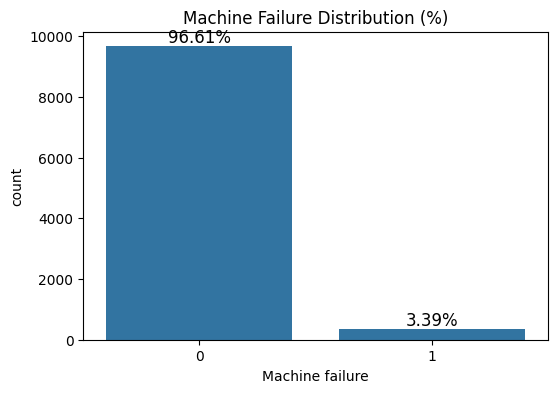

In [31]:
#Countplot for machine failure
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Machine failure')
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.2f}%', 
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom', fontsize=12)

plt.title("Machine Failure Distribution (%)")
plt.show()



C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_39072\7559273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


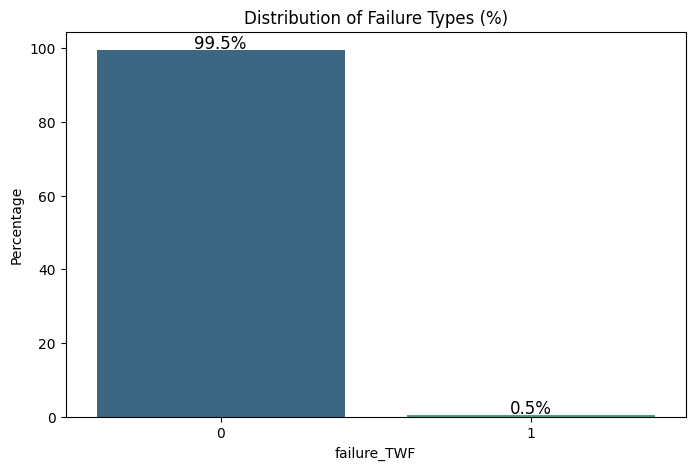

In [ ]:
# Failures caused by tool degradation: TWF
plt.figure(figsize=(8,5))
failure_TWF= df['TWF'].value_counts(normalize=True) * 100

ax = sns.barplot(
    x=failure_TWF.index,
    y=failure_TWF.values,
    palette="viridis"
)
for i, v in enumerate(failure_TWF.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12)

plt.title("Distribution of Failure Types (%)")
plt.ylabel("Percentage")
plt.xlabel("failure_TWF")
plt.show()

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_39072\2173792368.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


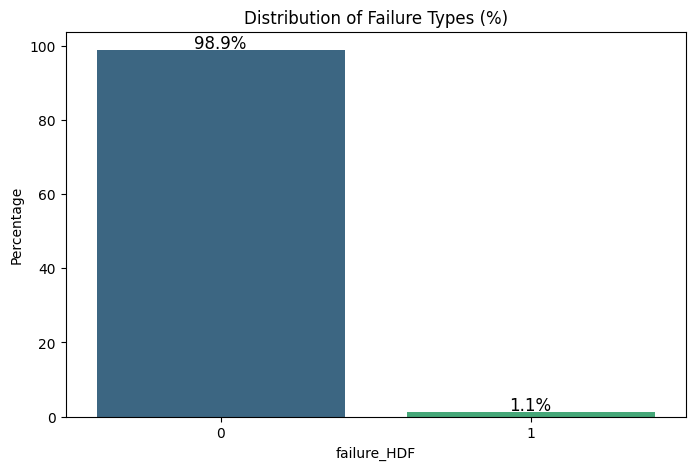

In [36]:
#: Failures due to overheating and inadequate thermal management: HDF
plt.figure(figsize=(8,5))
failure_HDF= df['HDF'].value_counts(normalize=True) * 100

ax = sns.barplot(
    x=failure_HDF.index,
    y=failure_HDF.values,
    palette="viridis"
)
for i, v in enumerate(failure_HDF.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12)

plt.title("Distribution of Failure Types (%)")
plt.ylabel("Percentage")
plt.xlabel("failure_HDF")
plt.show()

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_39072\3129875987.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


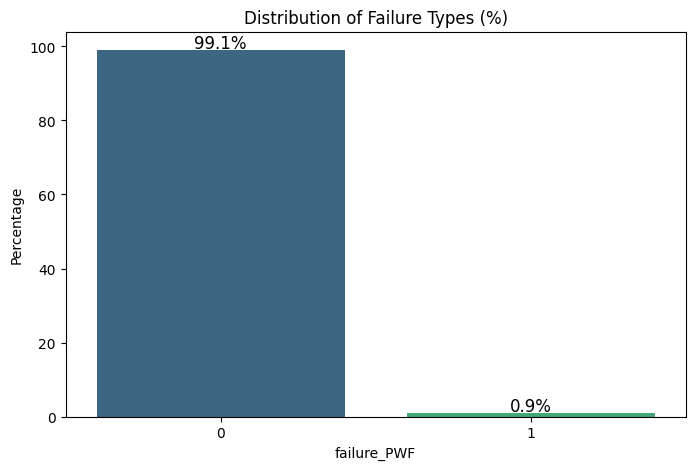

In [ ]:
#Failures resulting from power disruptions PWF
plt.figure(figsize=(8,5))
failure_PWF= df['PWF'].value_counts(normalize=True) * 100

ax = sns.barplot(
    x=failure_PWF.index,
    y=failure_PWF.values,
    palette="viridis"
)
for i, v in enumerate(failure_PWF.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12)

plt.title("Distribution of Failure Types (%)")
plt.ylabel("Percentage")
plt.xlabel("failure_PWF")
plt.show()

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_39072\4181553498.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


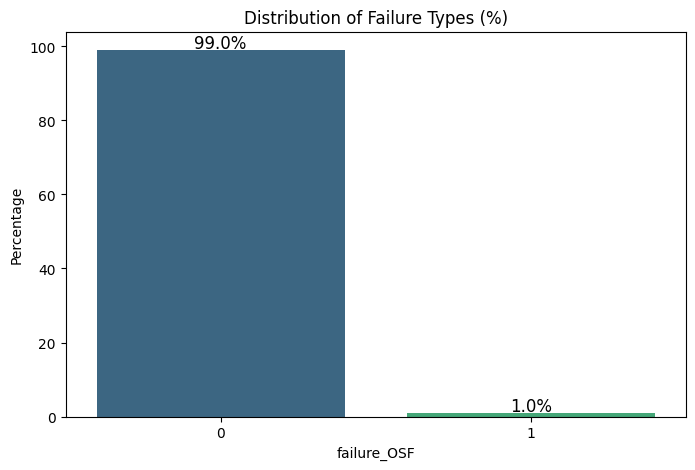

In [38]:
# Failures caused by excessive stress or strain on the machinery
plt.figure(figsize=(8,5))
failure_OSF= df['OSF'].value_counts(normalize=True) * 100

ax = sns.barplot(
    x=failure_OSF.index,
    y=failure_OSF.values,
    palette="viridis"
)
for i, v in enumerate(failure_OSF.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12)

plt.title("Distribution of Failure Types (%)")
plt.ylabel("Percentage")
plt.xlabel("failure_OSF")
plt.show()


C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_39072\2211955423.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


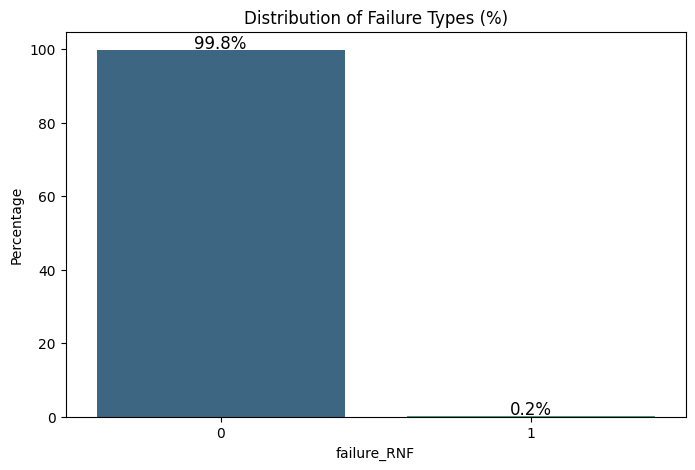

In [39]:
#RNF
plt.figure(figsize=(8,5))
failure_RNF= df['RNF'].value_counts(normalize=True) * 100

ax = sns.barplot(
    x=failure_RNF.index,
    y=failure_RNF.values,
    palette="viridis"
)
for i, v in enumerate(failure_RNF.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12)

plt.title("Distribution of Failure Types (%)")
plt.ylabel("Percentage")
plt.xlabel("failure_RNF")
plt.show()


In [42]:
# Co-occurence matrix
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
co_occurrence = df[failure_cols].T.dot(df[failure_cols])
co_occurrence




,TWF,HDF,PWF,OSF,RNF
TWF,46,0,1,3,1
HDF,0,115,3,6,0
PWF,1,3,95,12,0
OSF,3,6,12,98,0
RNF,1,0,0,0,19


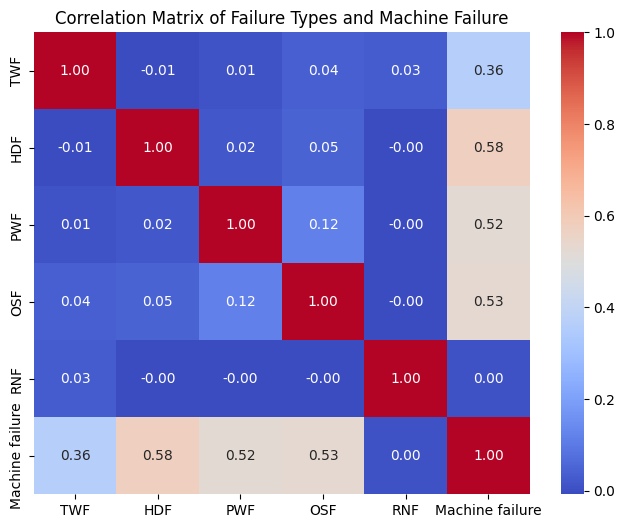

In [44]:
#Binary correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[failure_cols + ['Machine failure']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Failure Types and Machine Failure")
plt.show()


We just have 3.39% failures meaning that our data set is very imbalanced.We should pay attention during preprocessing and training. This provides a mathematical justification for choosing the Macro F1-Score as a measure of success, as overall accuracy would be a misleading indicator in this context.’

The two most common types of breakdown are: Failures due to overheating and inadequate thermal management: HDF 1.1% and Failures resulting from power disruptions PWF: 0.9%

Failure modes are almost always mutually exclusive: a machine typically exhibits only one type of failure. The only notable co-occurrence is between PWF (Power Failure) and OSF (Overstrain Failure), which may indicate a mechanical or electrical link between these two failure modes.

The faults most closely associated with machine failure are ‘OSF’, “PWF” and ‘HDF’

## 3. Feature Distributions & Quality

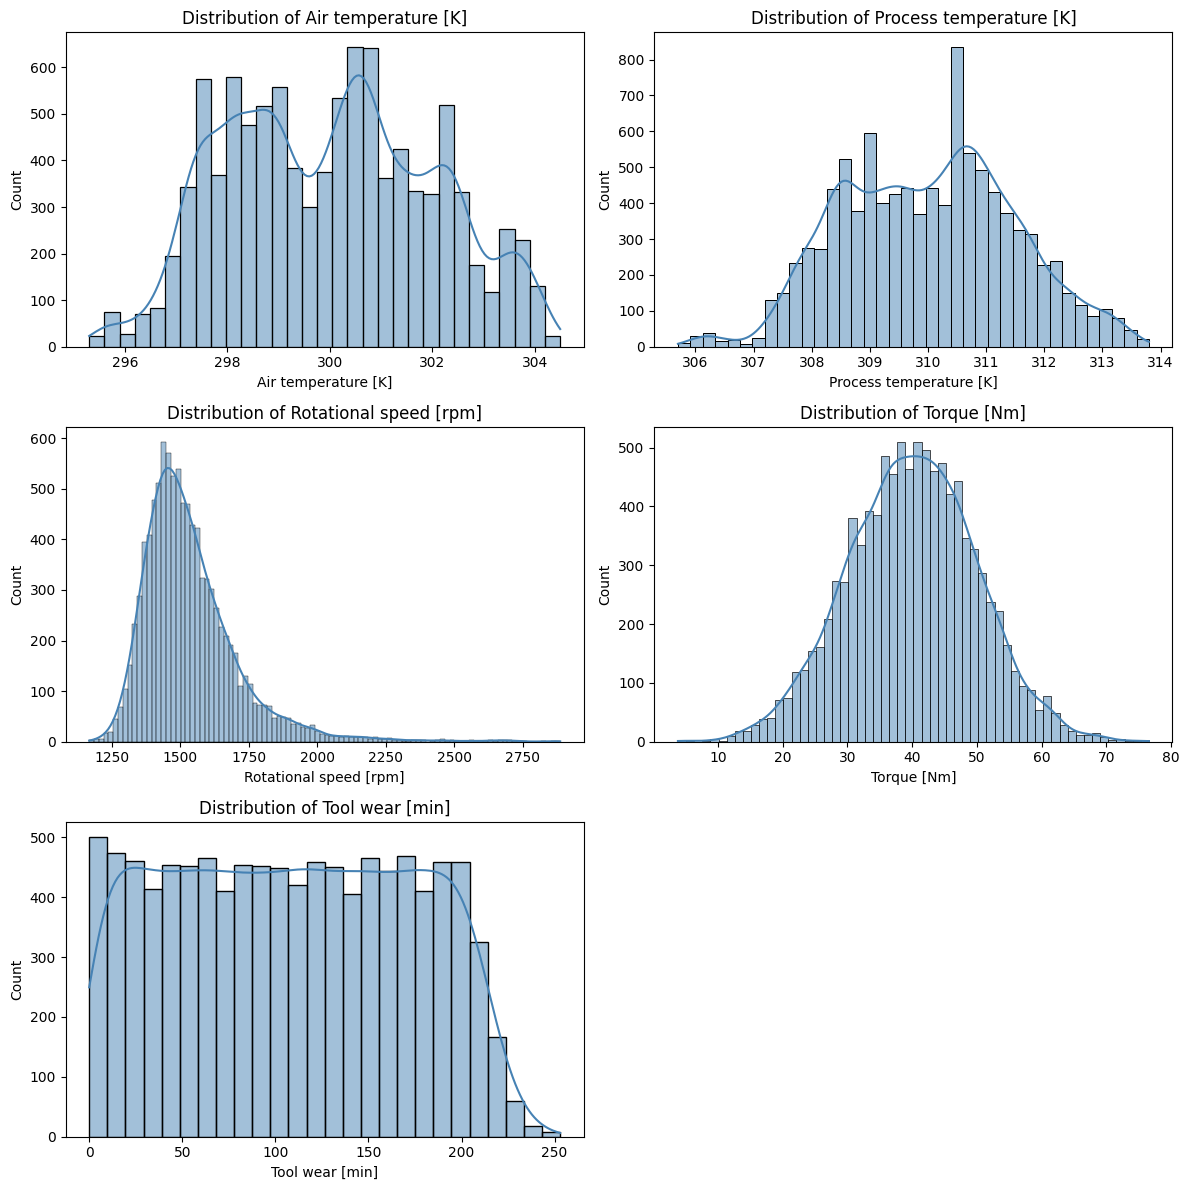

In [ ]:
# Histograms of numerical features
quant_vars = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
               'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(quant_vars):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis('off')
plt.tight_layout()
plt.show()


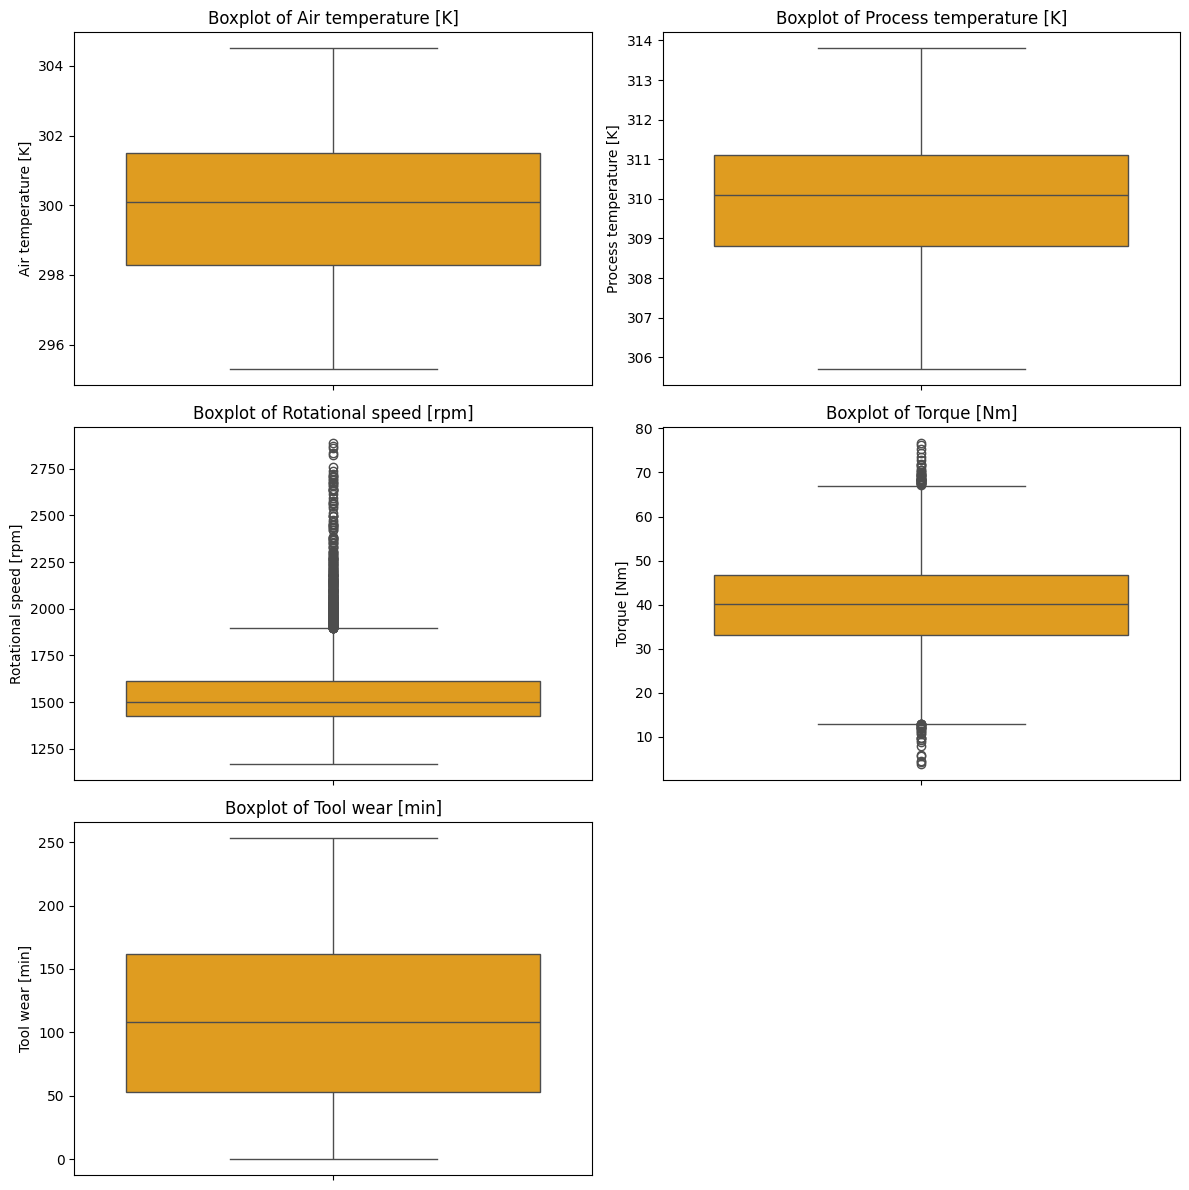

In [46]:
#Boxplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(quant_vars):
    sns.boxplot(y=df[col], ax=axes[i], color='orange')
    axes[i].set_title(f"Boxplot of {col}")
axes[-1].axis('off')

plt.tight_layout()
plt.show()


The histograms reveal a variety of patterns: some variables (Air temperature) are very stable, whilst others (Rotational speed, Torque, Tool wear) exhibit high variability or multimodal distributions. The box plots reveal the presence of outliers, particularly for Torque, Rotational speed and Tool wear, suggesting extreme operating conditions that may contribute to failures. These variables are likely to be the most informative for the predictive model.

Analysing distributions allows us to define the limits of a Data Quality Gate in Pandera. It would be useful to configure the thresholds to accommodate load spikes (high torque) that are precursors to failures, whilst blocking physically impossible values resulting from sensor errors.

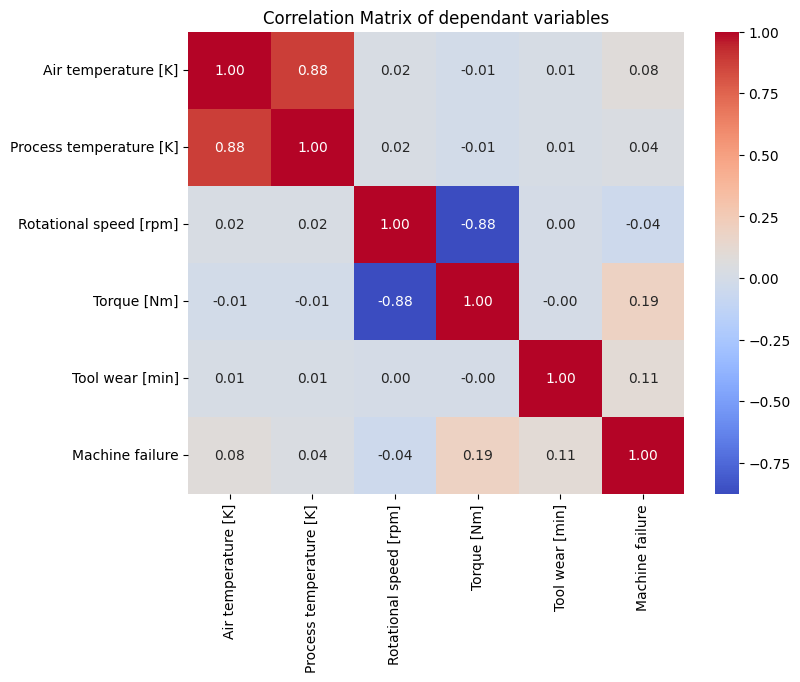

In [48]:
# Heatmap between independant variables
plt.figure(figsize=(8,6))
sns.heatmap(df[quant_vars+['Machine failure']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of dependant variables")
plt.show()

The correlation analysis reveals two pairs of strongly correlated variables: Air temperature and Process temperature (positive correlation of 0.88), and Torque and Rotational speed (strong negative correlation of -0.88). These relationships indicate potential redundancy of information and a risk of multicollinearity in linear models. For tree-based models, this is not a problem, but for linear models, regularisation or variable selection may be considered

## 4-Categorical impact

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_39072\1885929031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


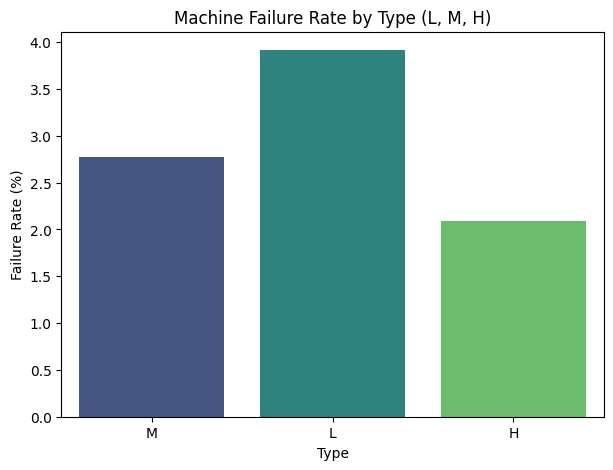

In [49]:
#Bar plot between "type" and "machine failure"
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x='Type',
    y='Machine failure',
    estimator=lambda x: x.mean() * 100,
    errorbar=None,
    palette='viridis'
)
plt.ylabel("Failure Rate (%)")
plt.title("Machine Failure Rate by Type (L, M, H)")
plt.show()


The Type variable (L, M, H) has a monotonic relationship with the probability of failure: machines of type H have a higher failure rate than those of type M, which in turn have a higher failure rate than those of type L. This ordered structure justifies the use of ordinal encoding rather than one-hot encoding, as the order contains information that is relevant to the model.

## 5-MLOps Strategy Summary

    Metric :F1-Macro (due to imbalance).

    Validation : 100% Schema enforcement (due to sensor outliers).

    Preprocessing : Ordinal encoding for 'Type' and median imputation for sensors.

    Optimization : LightGBM/XGBoost for tabular efficiency.